
.
# 03i — Independent Sanity Check of the 2003 National Drought-Core Peak

This notebook independently verifies the headline 2003 result reported by the
final M2A climatology: a very large maximum simultaneous drought-core area
(approximately 81% in the audited run).

It does **not** trust the 03d calculation blindly.

## Independent checks

1. Read the M2A detection NetCDF directly.
2. Recompute the 2003 national drought-core area using **plain NumPy** and
   cosine-latitude weights.
3. Recompute the same series using a separate **xarray** expression.
4. Compare both independent calculations with
   `annual_spatial_metrics_1996_2024.csv`.
5. Verify that:
   - all 2003 time steps contain exactly 73 pentads;
   - active `fd_drought_core == 1` cells occur only inside `valid_grid_mask`;
   - active drought-core cells have RZSM percentile <20 at the same pentad;
   - the reported peak pentad matches the independently recomputed peak pentad.
6. Report both area-weighted and raw unweighted grid fractions.

A passing result strengthens confidence that the large 2003 value is a genuine
property of the detection output rather than an area-weighting, mask, or
time-index bookkeeping error.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

BASE = Path(r"D:\ERA5_LAND")

DETECTION_FILE = (
    BASE
    / "output_fd_03b_sensitivity"
    / "fd_detection_M2A_1995_2025_indonesia.nc"
)

PERCENTILE_FILE = (
    BASE
    / "output_rzsm"
    / "rzsm_percentile_gringorten_1995_2025.nc"
)

ANNUAL_CSV = (
    BASE
    / "output_fd_03d_paper_climatology"
    / "annual_spatial_metrics_1996_2024.csv"
)

OUTPUT_DIR = (
    BASE
    / "output_fd_03i_qc_2003"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_YEAR = 2003
AREA_TOLERANCE_PERCENT_POINTS = 1e-5

for path in [
    DETECTION_FILE,
    PERCENTILE_FILE,
    ANNUAL_CSV,
]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Independent QC target year:", TARGET_YEAR)


Independent QC target year: 2003


In [2]:
det = xr.open_dataset(
    DETECTION_FILE,
    mask_and_scale=False,
)

valid = (
    det["valid_grid_mask"] == 1
).values.astype(bool)

lat = np.asarray(
    det["latitude"].values,
    dtype=float,
)
lon = np.asarray(
    det["longitude"].values,
    dtype=float,
)

year = np.asarray(
    det["year"].values,
    dtype=int,
)
pentad = np.asarray(
    det["pentad"].values,
    dtype=int,
)

idx = np.flatnonzero(
    year == TARGET_YEAR
)

if idx.size != 73:
    raise AssertionError(
        f"{TARGET_YEAR} must contain 73 pentads; found {idx.size}."
    )

if not np.array_equal(
    pentad[idx],
    np.arange(1, 74),
):
    raise AssertionError(
        f"{TARGET_YEAR} pentads are not ordered exactly 1..73."
    )

core_2003 = (
    det["fd_drought_core"]
    .isel(time_index=idx)
    .values == 1
)

# Core must never be active outside valid Indonesian grid cells.
invalid_core_count = int(
    np.sum(
        core_2003
        & (~valid[None, :, :])
    )
)

if invalid_core_count != 0:
    raise AssertionError(
        f"Found {invalid_core_count} active drought-core cells "
        "outside valid_grid_mask."
    )

print("Valid Indonesia grids:", int(valid.sum()))
print("2003 pentads:", idx.size)
print("Invalid active-core cells:", invalid_core_count)


Valid Indonesia grids: 14857
2003 pentads: 73
Invalid active-core cells: 0


In [3]:
# ============================================================
# Independent NumPy area-weighted calculation
# ============================================================
weights2d = (
    np.cos(np.deg2rad(lat))[:, None]
    * np.ones((lat.size, lon.size), dtype=np.float64)
)

denominator_numpy = float(
    np.sum(
        weights2d[valid]
    )
)

weighted_area_numpy = np.empty(
    idx.size,
    dtype=np.float64,
)

unweighted_area = np.empty(
    idx.size,
    dtype=np.float64,
)

for t in range(idx.size):
    active = (
        core_2003[t]
        & valid
    )

    weighted_area_numpy[t] = (
        np.sum(weights2d[active])
        / denominator_numpy
        * 100.0
    )

    unweighted_area[t] = (
        np.sum(active)
        / np.sum(valid)
        * 100.0
    )

peak_i_numpy = int(
    np.nanargmax(weighted_area_numpy)
)

peak_pentad_numpy = int(
    pentad[idx][peak_i_numpy]
)

peak_area_numpy = float(
    weighted_area_numpy[peak_i_numpy]
)

print(
    "NumPy peak:",
    f"{TARGET_YEAR} P{peak_pentad_numpy:02d}",
    f"{peak_area_numpy:.6f}%"
)


NumPy peak: 2003 P33 81.419568%


In [4]:
# ============================================================
# Separate xarray calculation
# ============================================================
core_da = (
    det["fd_drought_core"]
    .isel(time_index=idx) == 1
)

valid_da = (
    det["valid_grid_mask"] == 1
)

wlat = xr.DataArray(
    np.cos(
        np.deg2rad(
            det["latitude"].values
        )
    ),
    coords={
        "latitude": det["latitude"]
    },
    dims=("latitude",),
)

weight2d_xr = (
    wlat
    * xr.ones_like(
        valid_da,
        dtype=np.float64,
    )
).where(valid_da)

denominator_xr = float(
    weight2d_xr.sum().values
)

weighted_area_xr = (
    (
        core_da.astype(np.float64)
        * weight2d_xr
    )
    .sum(("latitude", "longitude"))
    / denominator_xr
    * 100.0
).values

max_numpy_xarray_diff = float(
    np.nanmax(
        np.abs(
            weighted_area_numpy
            - weighted_area_xr
        )
    )
)

if (
    max_numpy_xarray_diff
    > AREA_TOLERANCE_PERCENT_POINTS
):
    raise AssertionError(
        "Independent NumPy and xarray area calculations disagree: "
        f"max diff={max_numpy_xarray_diff}"
    )

print(
    "NumPy vs xarray maximum absolute difference:",
    max_numpy_xarray_diff,
    "percentage points"
)


NumPy vs xarray maximum absolute difference: 1.4210854715202004e-14 percentage points


In [5]:
# ============================================================
# Compare against 03d output
# ============================================================
annual = pd.read_csv(
    ANNUAL_CSV
)

row = annual.loc[
    annual["year"] == TARGET_YEAR
]

if len(row) != 1:
    raise AssertionError(
        f"Expected one annual row for {TARGET_YEAR}; found {len(row)}."
    )

row = row.iloc[0]

reported_area = float(
    row["maximum_drought_core_area_percent"]
)

reported_pentad = int(
    row["pentad_of_maximum_core_area"]
)

area_difference = float(
    peak_area_numpy
    - reported_area
)

area_match = bool(
    abs(area_difference)
    <= AREA_TOLERANCE_PERCENT_POINTS
)

pentad_match = bool(
    peak_pentad_numpy
    == reported_pentad
)

print(
    "03d reported peak:",
    f"{TARGET_YEAR} P{reported_pentad:02d}",
    f"{reported_area:.6f}%"
)

print(
    "Independent peak:",
    f"{TARGET_YEAR} P{peak_pentad_numpy:02d}",
    f"{peak_area_numpy:.6f}%"
)

print(
    "Difference:",
    f"{area_difference:+.8f} percentage points"
)

if not area_match:
    raise AssertionError(
        "Independent weighted peak area does not match 03d output."
    )

if not pentad_match:
    raise AssertionError(
        "Independent peak pentad does not match 03d output."
    )


03d reported peak: 2003 P33 81.419568%
Independent peak: 2003 P33 81.419568%
Difference: -0.00000000 percentage points


In [6]:
# ============================================================
# Threshold consistency against independently stored percentile cube
# ============================================================
pct_ds = xr.open_dataset(
    PERCENTILE_FILE
)

pct4 = (
    pct_ds["rzsm_percentile"]
    .transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )
)

pct_year = np.asarray(
    pct4["year"].values,
    dtype=int,
)
pct_pentad = np.asarray(
    pct4["pentad"].values,
    dtype=int,
)

if TARGET_YEAR not in pct_year:
    raise AssertionError(
        f"{TARGET_YEAR} not found in percentile cube."
    )

pct_2003 = (
    pct4
    .sel(year=TARGET_YEAR)
    .values
)

if pct_2003.shape[0] != 73:
    raise AssertionError(
        "Percentile cube does not contain 73 pentads for 2003."
    )

core_at_peak = (
    core_2003[peak_i_numpy]
    & valid
)

pct_at_peak = (
    pct_2003[
        peak_pentad_numpy - 1
    ]
)

core_with_missing_pct = int(
    np.sum(
        core_at_peak
        & (~np.isfinite(pct_at_peak))
    )
)

core_not_below_p20 = int(
    np.sum(
        core_at_peak
        & np.isfinite(pct_at_peak)
        & (pct_at_peak >= 20.0)
    )
)

if core_with_missing_pct != 0:
    raise AssertionError(
        f"{core_with_missing_pct} peak-core cells have missing RZSM percentile."
    )

if core_not_below_p20 != 0:
    raise AssertionError(
        f"{core_not_below_p20} peak-core cells have RZSM percentile >=20."
    )

print(
    "Peak drought-core cells:",
    int(core_at_peak.sum())
)
print(
    "Core cells with missing percentile:",
    core_with_missing_pct
)
print(
    "Core cells with percentile >=20:",
    core_not_below_p20
)


Peak drought-core cells: 12087
Core cells with missing percentile: 0
Core cells with percentile >=20: 0


In [7]:
# ============================================================
# Final QC table
# ============================================================
summary = pd.DataFrame([{
    "target_year": TARGET_YEAR,
    "reported_peak_pentad": reported_pentad,
    "independent_peak_pentad": peak_pentad_numpy,
    "reported_weighted_core_area_percent": reported_area,
    "independent_weighted_core_area_percent": peak_area_numpy,
    "independent_unweighted_core_grid_percent": float(
        unweighted_area[peak_i_numpy]
    ),
    "numpy_xarray_max_abs_diff_percentage_points": max_numpy_xarray_diff,
    "reported_minus_independent_abs_diff_percentage_points": abs(area_difference),
    "invalid_core_cells": invalid_core_count,
    "peak_core_cells_with_missing_percentile": core_with_missing_pct,
    "peak_core_cells_not_below_p20": core_not_below_p20,
    "area_match": area_match,
    "pentad_match": pentad_match,
    "overall_pass": bool(
        area_match
        and pentad_match
        and invalid_core_count == 0
        and core_with_missing_pct == 0
        and core_not_below_p20 == 0
    ),
}])

summary.to_csv(
    OUTPUT_DIR
    / "QC_2003_peak_summary.csv",
    index=False,
)

display(summary)

if not bool(
    summary["overall_pass"].iloc[0]
):
    raise AssertionError(
        "2003 peak sanity check FAILED."
    )

print(
    "PASS: the large 2003 peak is reproduced independently "
    "from the M2A detection output."
)


,target_year,reported_peak_pentad,independent_peak_pentad,reported_weighted_core_area_percent,independent_weighted_core_area_percent,independent_unweighted_core_grid_percent,numpy_xarray_max_abs_diff_percentage_points,reported_minus_independent_abs_diff_percentage_points,invalid_core_cells,peak_core_cells_with_missing_percentile,peak_core_cells_not_below_p20,area_match,pentad_match,overall_pass
0,2003,33,33,81.419568,81.419568,81.35559,1.421085e-14,1.421085e-14,0,0,0,True,True,True


PASS: the large 2003 peak is reproduced independently from the M2A detection output.


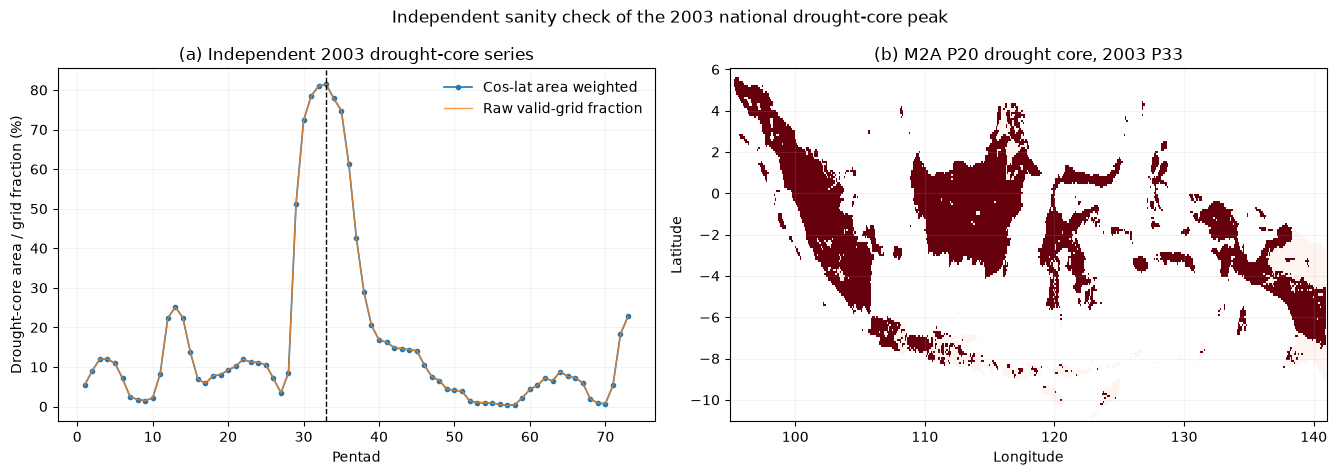

In [8]:
# ============================================================
# Diagnostic figure
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 4.8),
)

axes[0].plot(
    np.arange(1, 74),
    weighted_area_numpy,
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="Cos-lat area weighted",
)
axes[0].plot(
    np.arange(1, 74),
    unweighted_area,
    linewidth=1.0,
    alpha=0.8,
    label="Raw valid-grid fraction",
)
axes[0].axvline(
    peak_pentad_numpy,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(
    xlabel="Pentad",
    ylabel="Drought-core area / grid fraction (%)",
    title=f"(a) Independent {TARGET_YEAR} drought-core series",
)
axes[0].grid(alpha=0.15)
axes[0].legend(frameon=False)

peak_map = np.where(
    valid,
    core_2003[peak_i_numpy].astype(float),
    np.nan,
)

im = axes[1].pcolormesh(
    lon,
    lat,
    peak_map,
    shading="auto",
    cmap="Reds",
    vmin=0,
    vmax=1,
)
axes[1].set(
    xlabel="Longitude",
    ylabel="Latitude",
    title=(
        f"(b) M2A P20 drought core, "
        f"{TARGET_YEAR} P{peak_pentad_numpy:02d}"
    ),
)
axes[1].grid(alpha=0.15)

fig.suptitle(
    "Independent sanity check of the 2003 national drought-core peak"
)
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "QC_2003_peak_diagnostic.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

det.close()
pct_ds.close()
